# 🟦 TITRE

# Analyse de Churn Client – Online Retail II

## Objectif
Prédire le churn client et segmenter les comportements pour optimiser les stratégies marketing.

## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from xgboost import XGBClassifier
import shap

sns.set()

In [2]:
from xgboost import XGBClassifier
import shap

print("✅ XGBoost et SHAP fonctionnent parfaitement")

✅ XGBoost et SHAP fonctionnent parfaitement


# 🟩 DATASET

## Dataset

- Source : UCI Online Retail II
- Données transactionnelles (2009–2011)
- Chaque ligne = une transaction

### Problèmes
- Valeurs négatives (retours)
- Prix = 0
- Clients manquants

## 2. CHARGEMENT DONNÉES

In [3]:
print("⏳ Traitement en cours... Merci de patienter, cela peut prendre quelques minutes.")

file_path = "online_retail_II.xlsx"

df_2009 = pd.read_excel(file_path, sheet_name=0)
df_2010 = pd.read_excel(file_path, sheet_name=1)

df = pd.concat([df_2009, df_2010], ignore_index=True)

print("✅ Traitement terminé !")

df.head()

⏳ Traitement en cours... Merci de patienter, cela peut prendre quelques minutes.
✅ Traitement terminé !


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 🟨 NETTOYAGE

## Nettoyage des données

- Suppression des valeurs manquantes
- Suppression des retours (quantité négative)
- Création de la variable TotalPrice

## 3. NETTOYAGE

In [4]:
# Rename columns
df.rename(columns={'Customer ID': 'CustomerID', 'Invoice': 'InvoiceNo'}, inplace=True)

# Drop missing customers
df.dropna(subset=['CustomerID'], inplace=True)

# Remove returns (negative quantity)
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['Price'] > 0]

# Remove credit notes
df = df[df['InvoiceNo'].astype(str).str.startswith('C') == False]

# Convert types
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['Price']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


# 🟥 EDA

## 4. EDA (GRAPHIQUES)

### Top pays

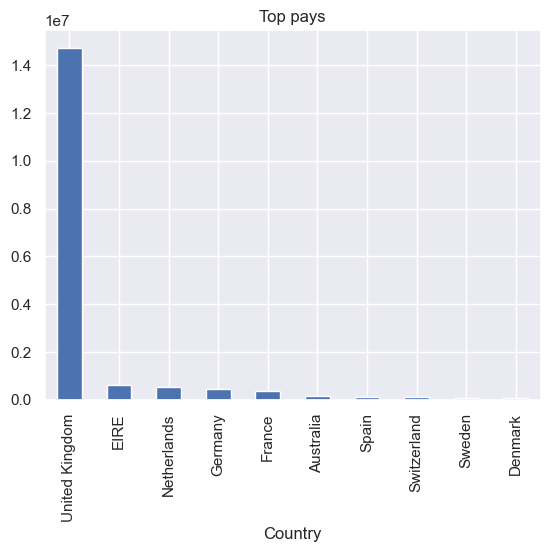

In [5]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top pays")
plt.show()

### Evolution ventes

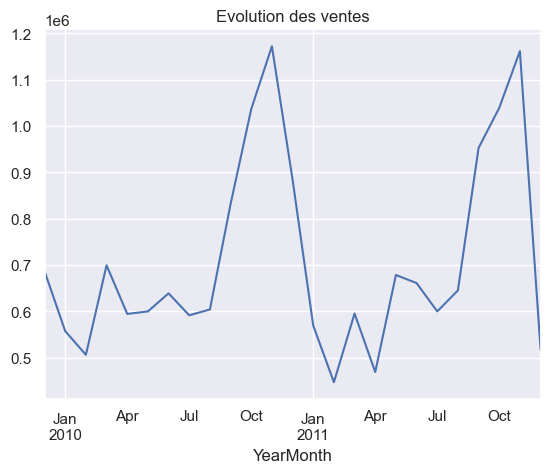

In [6]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

df.groupby('YearMonth')['TotalPrice'].sum().plot()
plt.title("Evolution des ventes")
plt.show()

### Distribution fréquence

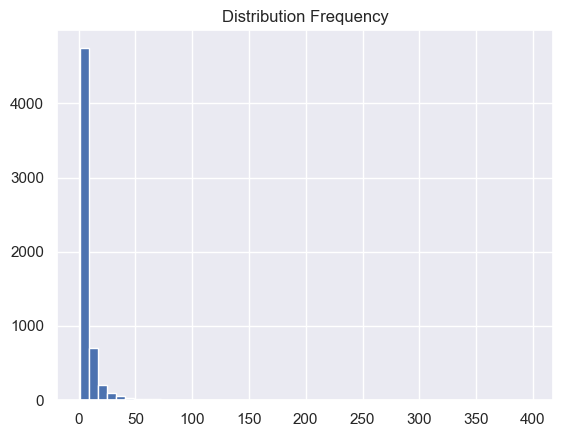

In [7]:
df.groupby('CustomerID')['InvoiceNo'].nunique().hist(bins=50)
plt.title("Distribution Frequency")
plt.show()

## Analyse exploratoire

### Pays
Le Royaume-Uni domine fortement les ventes.

### Évolution temporelle
Présence de saisonnalité (pics de ventes).

### Fréquence
Distribution très déséquilibrée :
- Beaucoup de clients occasionnels
- Peu de clients fidèles

# 🟪 RFM (Recence, Frequency, Monetary)

## 5. FEATURE ENGINEERING (RFM)

In [8]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Add Avg Basket
rfm['AvgBasket'] = rfm['Monetary'] / rfm['Frequency']

rfm.head()

,Recency,Frequency,Monetary,AvgBasket
CustomerID,,,,
12346,326,12,77556.46,6463.038333
12347,2,8,5633.32,704.165000
12348,75,5,2019.40,403.880000
12349,19,4,4428.69,1107.172500
12350,310,1,334.40,334.400000


## Analyse RFM

- Recency : récence d’achat
- Frequency : fréquence
- Monetary : valeur

Permet de capturer le comportement client

# 🟧 CHURN

## Définition du churn

Un client est considéré comme churn s’il n’effectue aucun achat dans le futur.

✅ Approche temporelle utilisée pour éviter le data leakage ou la fuite de données

## 6. CONSTRUCTION DU CHURN (TEMPOREL)

In [9]:
split_date = '2011-01-01'

df_train = df[df['InvoiceDate'] < split_date]
df_test = df[df['InvoiceDate'] >= split_date]

# Rebuild RFM on train
snapshot = df_train['InvoiceDate'].max()

rfm = df_train.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

# Future purchases
future = df_test.groupby('CustomerID')['InvoiceNo'].count()

rfm['FuturePurchase'] = rfm.index.map(future).fillna(0)

rfm['Churn'] = (rfm['FuturePurchase'] == 0).astype(int)

rfm.head()

,Recency,Frequency,Monetary,FuturePurchase,Churn
CustomerID,,,,,
12346,178,11,372.86,1.0,0
12347,16,2,2035.11,151.0,0
12348,6,2,1114.96,14.0,0
12349,56,3,2671.14,73.0,0
12351,24,1,300.93,0.0,1


# 🟫 MODÉLISATION

## Modélisation

### Modèles utilisés :
- Random Forest
- XGradienBoost

### Résultat :
- XGgradienBoost meilleur modèle
- Bonne capacité de prédiction du churn

## 7. MODÉLISATION (RF + XGBOOST)

### Split

In [22]:
X = rfm[['Frequency','Monetary','Recency']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Random Forest

In [23]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76       804
           1       0.61      0.57      0.59       499

    accuracy                           0.69      1303
   macro avg       0.68      0.67      0.67      1303
weighted avg       0.69      0.69      0.69      1303



### Matrice de confusion

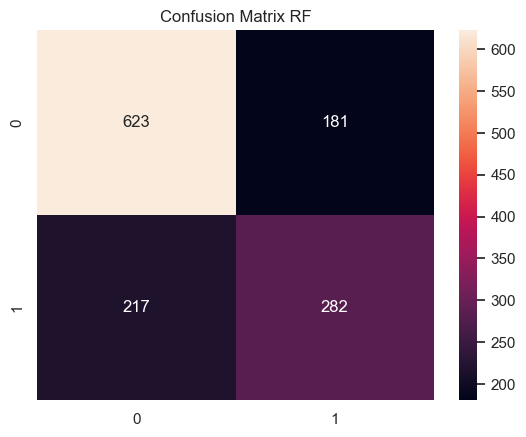

In [24]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix RF")
plt.show()

### XGradientBoost

In [13]:
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       841
           1       0.62      0.60      0.61       462

    accuracy                           0.73      1303
   macro avg       0.70      0.70      0.70      1303
weighted avg       0.72      0.73      0.72      1303



### Matrice de confusion

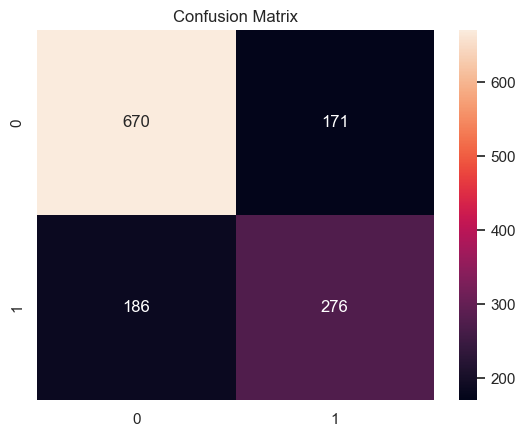

In [14]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix GB")
plt.show()

# 🟦 SHAP

## Explicabilité (SHAP)

- Permet d’interpréter le modèle
- Variables importantes :
  - Frequency
  - Monetary

Les clients fréquents churn moins

## 8. SHAP (EXPLICATION)

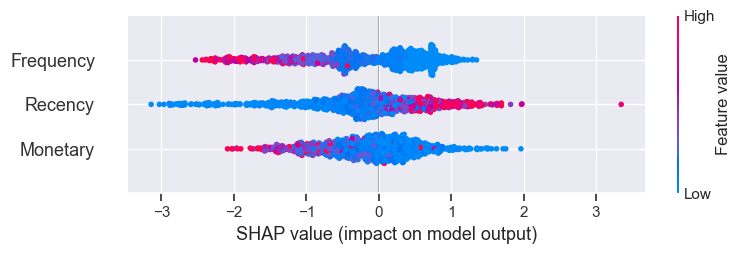

In [15]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# 🟩 CLUSTERING

## Segmentation client

KMeans utilisé pour identifier 4 groupes :

- VIP
- Clients actifs
- Clients à risque
- Clients perdus

👉 Utile pour stratégie marketing

## 9. CLUSTERING (KMeans + PCA)

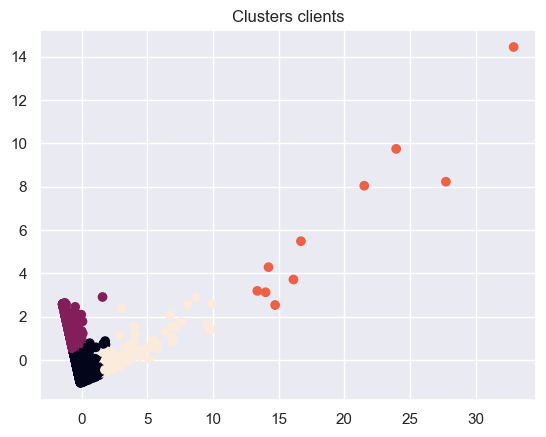

In [16]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=rfm['Cluster'])
plt.title("Clusters clients")
plt.show()

### Analyse clusters

In [18]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,52.807195,4.059956,1571.041706
1,257.038500,1.629812,587.801040
2,7.800000,122.400000,143459.009000
3,17.533333,27.306667,15973.689687


## 10. CONCLUSION BUSINESS

In [19]:
print("INSIGHTS BUSINESS")
print("- Forte présence de clients occasionnels")
print("- Les clients avec haute fréquence churn moins")
print("- Le marché est dominé par UK")
print("- Besoin de stratégie de fidélisation")

INSIGHTS BUSINESS
- Forte présence de clients occasionnels
- Les clients avec haute fréquence churn moins
- Le marché est dominé par UK
- Besoin de stratégie de fidélisation


## VARIABLES IMPORTANTES (POINT INTÉRESSANT)

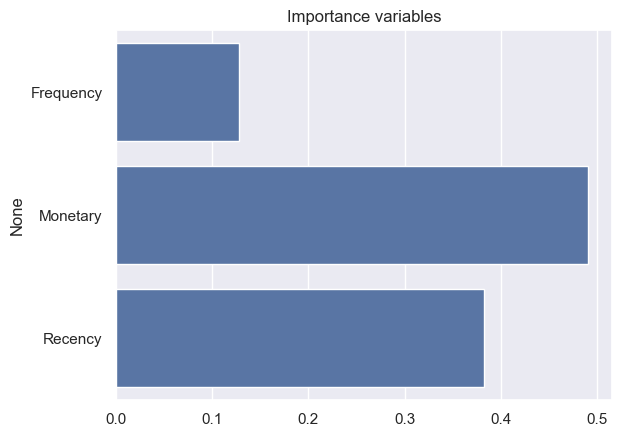

In [20]:
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Importance variables")
plt.show()

# 🟥 CONCLUSION

## Conclusion

- Fort churn (clients occasionnels)
- Forte dépendance au marché UK
- Clients fidèles = forte valeur

### Recommandations
- Fidélisation clients VIP
- Relance clients à risque
- Expansion internationale